<a href="https://colab.research.google.com/github/amitgupta226571/DEEP-LEARNING-/blob/main/Experiment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Set path for Experiment 10
import os
exp_path = '/content/drive/MyDrive/DEEP LEARNING LAB/Experiment 10'
os.makedirs(exp_path, exist_ok=True)
os.makedirs(f'{exp_path}/models', exist_ok=True)
os.makedirs(f'{exp_path}/results', exist_ok=True)

print(f"✅ Results will be saved to: {exp_path}")

Mounted at /content/drive
✅ Results will be saved to: /content/drive/MyDrive/DEEP LEARNING LAB/Experiment 10


In [2]:
!pip install -q wandb torch torchvision matplotlib numpy tqdm scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from sklearn.metrics import accuracy_score, classification_report
import time

# Set seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


100%|██████████| 170M/170M [00:05<00:00, 29.0MB/s]


Dataset split:
  Training: 40000 samples (80%)
  Validation: 5000 samples (10%)
  Test: 10000 samples (10%)


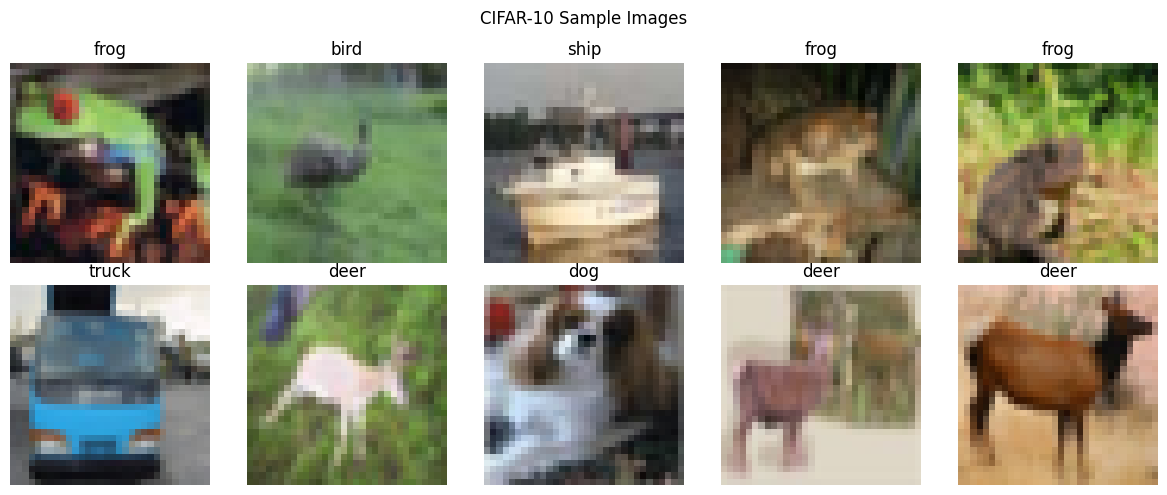

In [3]:
# CIFAR-10 classes
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Define transforms (without augmentation for baseline)
transform_train_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load full dataset
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_base)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Split training into train (80%) and validation (10% of total = 12.5% of train)
train_size = int(0.8 * len(full_train))
val_size = int(0.1 * len(full_train))
remaining = len(full_train) - train_size - val_size

train_dataset, val_dataset, _ = torch.utils.data.random_split(
    full_train, [train_size, val_size, remaining]
)

print(f"Dataset split:")
print(f"  Training: {len(train_dataset)} samples (80%)")
print(f"  Validation: {len(val_dataset)} samples (10%)")
print(f"  Test: {len(test_dataset)} samples (10%)")

# Show sample images
def show_sample_images():
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i in range(10):
        img, label = train_dataset[i]
        img = img.permute(1, 2, 0).numpy()
        # Denormalize for display
        img = img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])
        img = np.clip(img, 0, 1)
        axes[i//5, i%5].imshow(img)
        axes[i//5, i%5].set_title(CIFAR10_CLASSES[label])
        axes[i//5, i%5].axis('off')
    plt.suptitle('CIFAR-10 Sample Images')
    plt.tight_layout()
    plt.show()

show_sample_images()

Augmented dataset created:
  Training: 40000 samples (with flips)
  Validation: 5000 samples


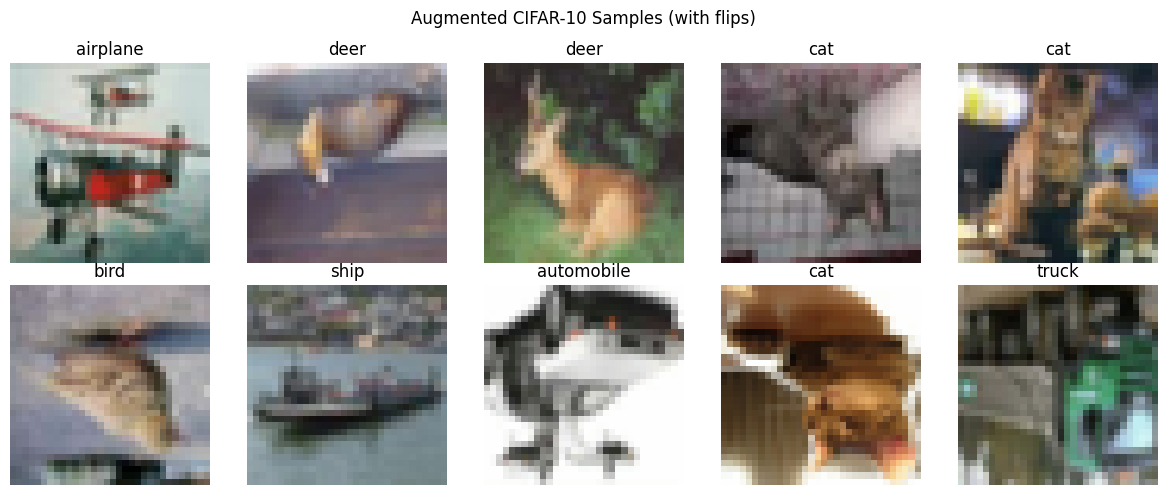

In [4]:
# Augmented transforms with horizontal and vertical flips
transform_train_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Create augmented training dataset
train_dataset_augmented = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train_augmented
)

# Split augmented dataset
train_size_aug = int(0.8 * len(train_dataset_augmented))
val_size_aug = int(0.1 * len(train_dataset_augmented))

train_dataset_aug, val_dataset_aug, _ = torch.utils.data.random_split(
    train_dataset_augmented, [train_size_aug, val_size_aug, remaining]
)

print(f"Augmented dataset created:")
print(f"  Training: {len(train_dataset_aug)} samples (with flips)")
print(f"  Validation: {len(val_dataset_aug)} samples")

# Visualize augmented samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    img, label = train_dataset_aug[i]
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])
    img = np.clip(img, 0, 1)
    axes[i//5, i%5].imshow(img)
    axes[i//5, i%5].set_title(CIFAR10_CLASSES[label])
    axes[i//5, i%5].axis('off')
plt.suptitle('Augmented CIFAR-10 Samples (with flips)')
plt.tight_layout()
plt.show()

In [5]:
class PatchEmbedding(nn.Module):
    """Convert image to patch embeddings"""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/patch, W/patch)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x

class PositionalEncoding(nn.Module):
    """Learnable positional encoding"""
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

    def forward(self, x):
        return x + self.pos_embed

class TransformerEncoder(nn.Module):
    """Single transformer encoder block"""
    def __init__(self, embed_dim=128, num_heads=8, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # Self-attention with residual
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)

        # MLP with residual
        mlp_out = self.mlp(x)
        x = self.norm2(x + mlp_out)
        return x

class VisionTransformer(nn.Module):
    """Complete Vision Transformer for classification"""
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=128, num_heads=8, num_layers=6, hidden_dim=512, dropout=0.1):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # CLS token
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Positional encoding
        self.pos_embed = PositionalEncoding(num_patches, embed_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Transformer encoders
        self.encoder = nn.ModuleList([
            TransformerEncoder(embed_dim, num_heads, hidden_dim, dropout)
            for _ in range(num_layers)
        ])

        # Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)

        # Add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, num_patches+1, embed_dim)

        # Add positional encoding
        x = self.pos_embed(x)
        x = self.dropout(x)

        # Pass through transformer encoders
        for encoder in self.encoder:
            x = encoder(x)

        # Use CLS token for classification
        cls_out = x[:, 0, :]
        cls_out = self.norm(cls_out)
        output = self.classifier(cls_out)

        return output

# Test ViT
test_vit = VisionTransformer(img_size=32, patch_size=4, num_classes=10)
test_input = torch.randn(4, 3, 32, 32)
test_output = test_vit(test_input)
print(f"ViT model - Input shape: {test_input.shape}, Output shape: {test_output.shape}")
print(f"Total parameters: {sum(p.numel() for p in test_vit.parameters()):,}")

ViT model - Input shape: torch.Size([4, 3, 32, 32]), Output shape: torch.Size([4, 10])
Total parameters: 1,205,898


In [6]:
import torchvision.models as models

class ResNet18(nn.Module):
    """ResNet-18 for CIFAR-10"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=None)
        # Modify first conv layer for CIFAR-10 (32x32 instead of 224x224)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()  # Remove maxpool
        self.model.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        return self.model(x)

# Test ResNet
test_resnet = ResNet18(num_classes=10)
test_output = test_resnet(test_input)
print(f"ResNet-18 - Input shape: {test_input.shape}, Output shape: {test_output.shape}")
print(f"Total parameters: {sum(p.numel() for p in test_resnet.parameters()):,}")

ResNet-18 - Input shape: torch.Size([4, 3, 32, 32]), Output shape: torch.Size([4, 10])
Total parameters: 11,173,962


In [7]:
class LabelSmoothingLoss(nn.Module):
    """Cross-entropy with label smoothing"""
    def __init__(self, smoothing=0.1, num_classes=10):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, pred, target):
        log_probs = nn.functional.log_softmax(pred, dim=-1)
        with torch.no_grad():
            # Create smoothed targets
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

class FocalLoss(nn.Module):
    """Focal Loss for hard examples"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred, target):
        ce_loss = nn.functional.cross_entropy(pred, target, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

def get_loss_function(loss_type):
    """Factory function for loss functions"""
    if loss_type == 'cross_entropy':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smoothing':
        return LabelSmoothingLoss(smoothing=0.1, num_classes=10)
    elif loss_type == 'focal':
        return FocalLoss(alpha=0.25, gamma=2.0)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

In [8]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(train_loader), 100. * correct / total

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(val_loader), 100. * correct / total

def train_model(model, train_loader, val_loader, config, model_name):
    """Complete training pipeline"""
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"Config: Loss={config['loss_type']}, Optimizer={config['optimizer']}, Augmentation={config['augmentation']}")
    print(f"{'='*60}")

    # Setup optimizer
    if config['optimizer'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    elif config['optimizer'] == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=config['learning_rate'])
    else:  # sgd
        optimizer = optim.SGD(model.parameters(), lr=config['learning_rate'], momentum=0.9, weight_decay=5e-4)

    # Setup loss
    criterion = get_loss_function(config['loss_type'])

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0

    for epoch in range(config['epochs']):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"{exp_path}/models/{model_name}_best.pt")

        # Print progress
        print(f"Epoch {epoch+1}/{config['epochs']}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    print(f"\n✅ Training complete! Best validation accuracy: {best_val_acc:.2f}%")

    return model, history

In [9]:
batch_size = 128
epochs = 30
learning_rate = 0.001

# Create data loaders for original and augmented datasets
train_loader_base = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_base = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=False)

# Configurations to test
loss_types = ['cross_entropy', 'label_smoothing', 'focal']
optimizers = ['adam', 'sgd', 'rmsprop']
augmentations = [False, True]

print("Experiment configurations ready!")
print(f"Loss functions: {loss_types}")
print(f"Optimizers: {optimizers}")
print(f"Augmentations: {augmentations}")

Experiment configurations ready!
Loss functions: ['cross_entropy', 'label_smoothing', 'focal']
Optimizers: ['adam', 'sgd', 'rmsprop']
Augmentations: [False, True]



Training ResNet18_cross_entropy_adam_base
Config: Loss=cross_entropy, Optimizer=adam, Augmentation=False


Validation: 100%|██████████| 40/40 [00:03<00:00, 10.11it/s]


Epoch 1/30: Train Loss: 1.2939, Train Acc: 53.13%, Val Loss: 1.1218, Val Acc: 60.42%


Validation: 100%|██████████| 40/40 [00:02<00:00, 18.50it/s]


Epoch 2/30: Train Loss: 0.8066, Train Acc: 71.33%, Val Loss: 0.7465, Val Acc: 74.22%


...

Epoch 28/30: Train Loss: 0.0181, Train Acc: 99.44%, Val Loss: 0.9134, Val Acc: 83.18%


Validation: 100%|██████████| 40/40 [00:02<00:00, 18.23it/s]


Epoch 29/30: Train Loss: 0.0171, Train Acc: 99.41%, Val Loss: 0.9518, Val Acc: 83.06%


Validation: 100%|██████████| 40/40 [00:02<00:00, 14.78it/s]


Epoch 30/30: Train Loss: 0.0313, Train Acc: 98.96%, Val Loss: 0.9622, Val Acc: 81.66%

✅ Training complete! Best validation accuracy: 83.68%


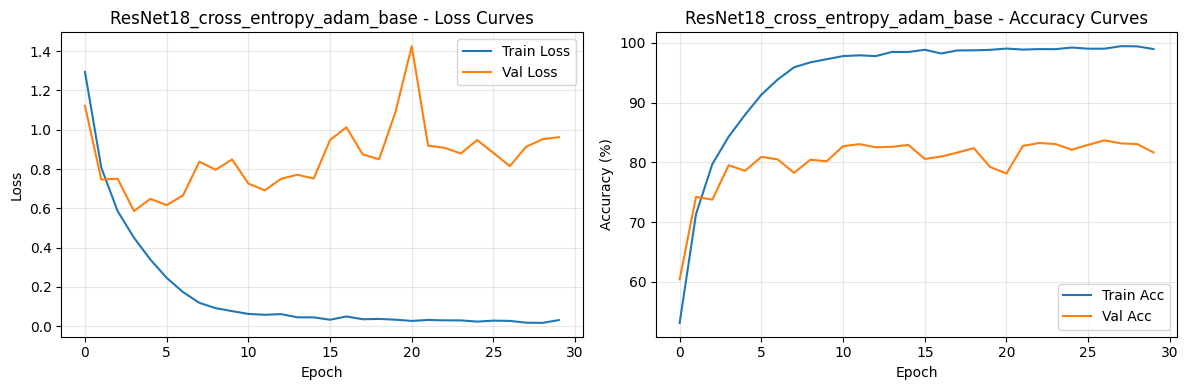


Training ResNet18_cross_entropy_adam_aug
Config: Loss=cross_entropy, Optimizer=adam, Augmentation=True


Validation: 100%|██████████| 40/40 [00:02<00:00, 15.86it/s]


Epoch 1/30: Train Loss: 1.4500, Train Acc: 46.16%, Val Loss: 1.3284, Val Acc: 52.62%


Validation: 100%|██████████| 40/40 [00:02<00:00, 13.46it/s]


Epoch 2/30: Train Loss: 1.0185, Train Acc: 62.91%, Val Loss: 1.0052, Val Acc: 65.12%


...

Epoch 28/30: Train Loss: 0.0859, Train Acc: 96.96%, Val Loss: 0.5788, Val Acc: 84.46%


Validation: 100%|██████████| 40/40 [00:02<00:00, 15.99it/s]


Epoch 29/30: Train Loss: 0.0896, Train Acc: 96.91%, Val Loss: 0.5806, Val Acc: 85.02%


Validation: 100%|██████████| 40/40 [00:02<00:00, 15.20it/s]


Epoch 30/30: Train Loss: 0.0794, Train Acc: 97.15%, Val Loss: 0.6240, Val Acc: 84.48%

✅ Training complete! Best validation accuracy: 85.24%


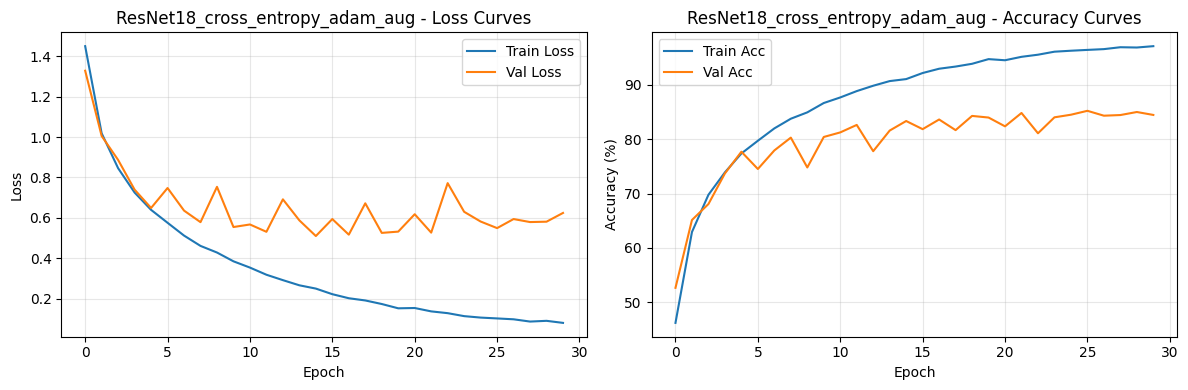

In [10]:
resnet_results = {}

# Test ResNet-18 with different configurations
for aug in augmentations:
    for loss in loss_types[:1]:  # Test only cross_entropy first
        for opt in optimizers[:1]:  # Test only Adam first
            config = {
                'loss_type': loss,
                'optimizer': opt,
                'learning_rate': learning_rate,
                'epochs': epochs,
                'augmentation': aug
            }

            model_name = f"ResNet18_{loss}_{opt}_{'aug' if aug else 'base'}"

            # Select data loader
            train_loader = train_loader_aug if aug else train_loader_base
            val_loader = val_loader_aug if aug else val_loader_base

            # Create and train model
            model = ResNet18(num_classes=10).to(device)
            model, history = train_model(model, train_loader, val_loader, config, model_name)

            resnet_results[model_name] = {
                'model': model,
                'history': history,
                'config': config
            }

            # Plot training curves
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            axes[0].plot(history['train_loss'], label='Train Loss')
            axes[0].plot(history['val_loss'], label='Val Loss')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].set_title(f'{model_name} - Loss Curves')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            axes[1].plot(history['train_acc'], label='Train Acc')
            axes[1].plot(history['val_acc'], label='Val Acc')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Accuracy (%)')
            axes[1].set_title(f'{model_name} - Accuracy Curves')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig(f"{exp_path}/results/{model_name}_curves.png")
            plt.show()


Training ViT_cross_entropy_adam_base
Config: Loss=cross_entropy, Optimizer=adam, Augmentation=False


Validation: 100%|██████████| 40/40 [00:01<00:00, 24.53it/s]


Epoch 1/30: Train Loss: 1.7094, Train Acc: 37.01%, Val Loss: 1.3759, Val Acc: 50.90%


Validation: 100%|██████████| 40/40 [00:01<00:00, 24.63it/s]


Epoch 2/30: Train Loss: 1.3894, Train Acc: 49.33%, Val Loss: 1.2519, Val Acc: 56.16%


...

Epoch 28/30: Train Loss: 0.4662, Train Acc: 83.35%, Val Loss: 1.0211, Val Acc: 68.60%


Validation: 100%|██████████| 40/40 [00:02<00:00, 19.22it/s]


Epoch 29/30: Train Loss: 0.4589, Train Acc: 83.50%, Val Loss: 1.0028, Val Acc: 69.62%


Validation: 100%|██████████| 40/40 [00:02<00:00, 18.53it/s]


Epoch 30/30: Train Loss: 0.4348, Train Acc: 84.42%, Val Loss: 1.0744, Val Acc: 67.82%

✅ Training complete! Best validation accuracy: 69.88%


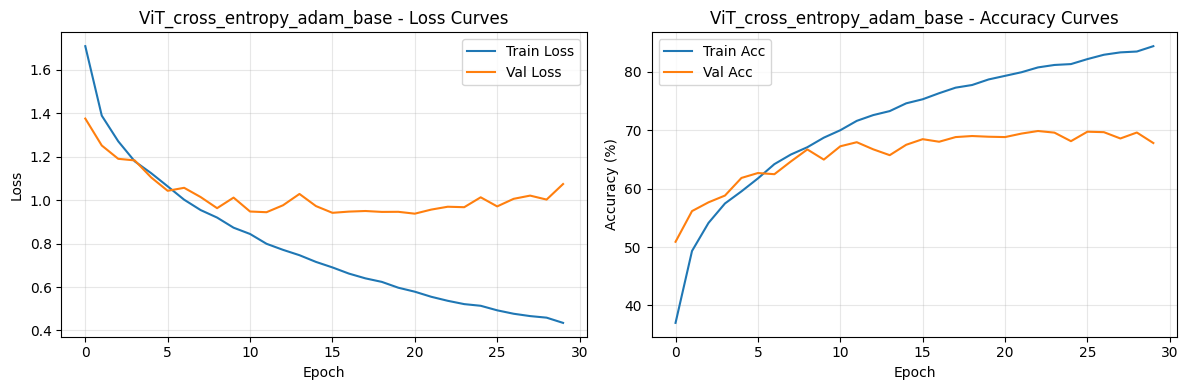


Training ViT_cross_entropy_adam_aug
Config: Loss=cross_entropy, Optimizer=adam, Augmentation=True


Validation: 100%|██████████| 40/40 [00:02<00:00, 19.76it/s]


Epoch 1/30: Train Loss: 1.8442, Train Acc: 31.41%, Val Loss: 1.6185, Val Acc: 39.78%


Validation: 100%|██████████| 40/40 [00:01<00:00, 20.22it/s]


Epoch 2/30: Train Loss: 1.5361, Train Acc: 43.52%, Val Loss: 1.4597, Val Acc: 46.92%


...

Epoch 28/30: Train Loss: 0.6420, Train Acc: 76.73%, Val Loss: 1.0482, Val Acc: 66.62%


Validation: 100%|██████████| 40/40 [00:02<00:00, 15.14it/s]


Epoch 29/30: Train Loss: 0.6267, Train Acc: 77.20%, Val Loss: 1.0132, Val Acc: 67.68%


Validation: 100%|██████████| 40/40 [00:02<00:00, 18.04it/s]


Epoch 30/30: Train Loss: 0.6046, Train Acc: 78.12%, Val Loss: 0.9939, Val Acc: 66.88%

✅ Training complete! Best validation accuracy: 68.44%


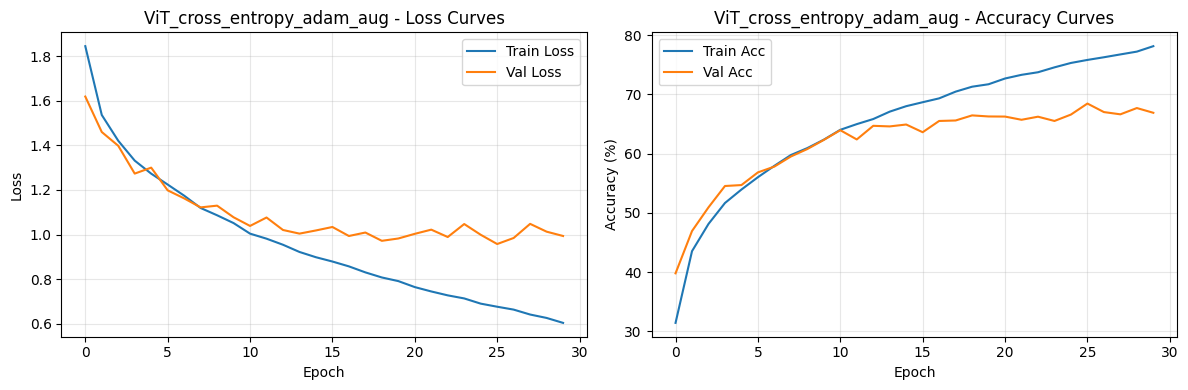

In [11]:
vit_results = {}

# Test ViT with different configurations
for aug in augmentations:
    for loss in loss_types[:1]:  # Test only cross_entropy first
        for opt in optimizers[:1]:  # Test only Adam first
            config = {
                'loss_type': loss,
                'optimizer': opt,
                'learning_rate': learning_rate,
                'epochs': epochs,
                'augmentation': aug
            }

            model_name = f"ViT_{loss}_{opt}_{'aug' if aug else 'base'}"

            # Select data loader
            train_loader = train_loader_aug if aug else train_loader_base
            val_loader = val_loader_aug if aug else val_loader_base

            # Create and train model
            model = VisionTransformer(img_size=32, patch_size=4, num_classes=10).to(device)
            model, history = train_model(model, train_loader, val_loader, config, model_name)

            vit_results[model_name] = {
                'model': model,
                'history': history,
                'config': config
            }

            # Plot training curves
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            axes[0].plot(history['train_loss'], label='Train Loss')
            axes[0].plot(history['val_loss'], label='Val Loss')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].set_title(f'{model_name} - Loss Curves')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            axes[1].plot(history['train_acc'], label='Train Acc')
            axes[1].plot(history['val_acc'], label='Val Acc')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Accuracy (%)')
            axes[1].set_title(f'{model_name} - Accuracy Curves')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig(f"{exp_path}/results/{model_name}_curves.png")
            plt.show()

In [12]:
def evaluate_on_test(model, test_loader, device, model_name):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_preds) * 100
    return accuracy, all_preds, all_labels

# Evaluate ResNet-18 models
print("\n" + "="*60)
print("TEST SET EVALUATION - RESNET-18")
print("="*60)

resnet_test_accuracies = {}
for name, result in resnet_results.items():
    acc, _, _ = evaluate_on_test(result['model'], test_loader, device, name)
    resnet_test_accuracies[name] = acc
    print(f"{name}: {acc:.2f}%")

# Evaluate ViT models
print("\n" + "="*60)
print("TEST SET EVALUATION - VISION TRANSFORMER")
print("="*60)

vit_test_accuracies = {}
for name, result in vit_results.items():
    acc, _, _ = evaluate_on_test(result['model'], test_loader, device, name)
    vit_test_accuracies[name] = acc
    print(f"{name}: {acc:.2f}%")


TEST SET EVALUATION - RESNET-18


Evaluating ResNet18_cross_entropy_adam_base: 100%|██████████| 79/79 [00:04<00:00, 18.17it/s]


ResNet18_cross_entropy_adam_base: 81.57%


Evaluating ResNet18_cross_entropy_adam_aug: 100%|██████████| 79/79 [00:04<00:00, 17.30it/s]


ResNet18_cross_entropy_adam_aug: 84.46%

TEST SET EVALUATION - VISION TRANSFORMER


Evaluating ViT_cross_entropy_adam_base: 100%|██████████| 79/79 [00:04<00:00, 18.38it/s]


ViT_cross_entropy_adam_base: 68.17%


Evaluating ViT_cross_entropy_adam_aug: 100%|██████████| 79/79 [00:03<00:00, 21.54it/s]

ViT_cross_entropy_adam_aug: 67.26%


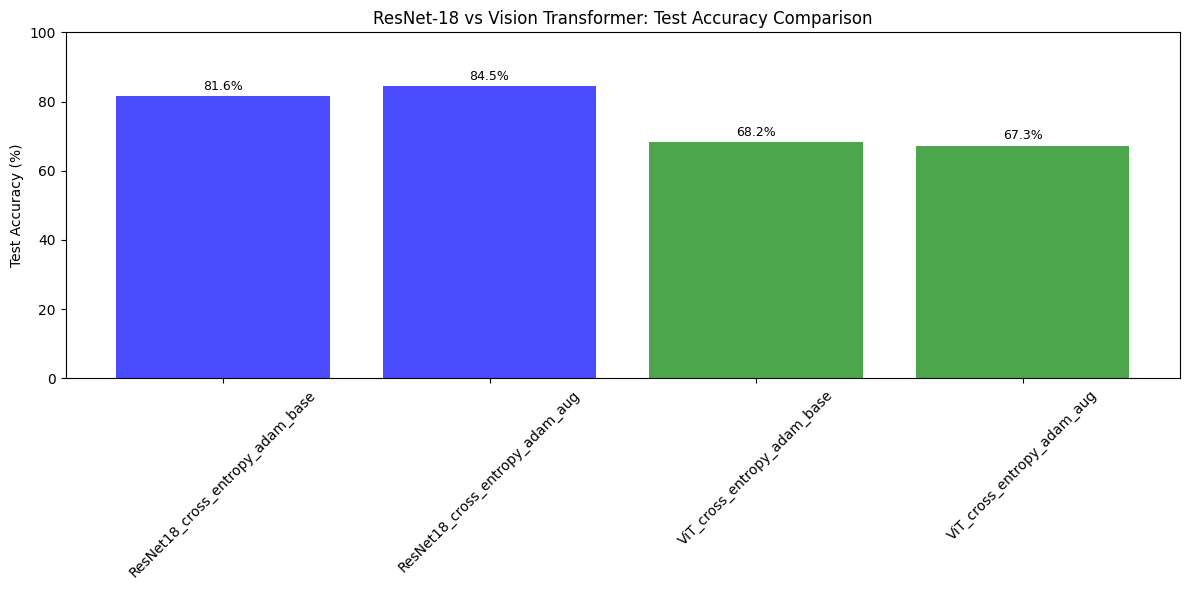


EXPERIMENT 10: FINAL RESULTS SUMMARY

📊 RESNET-18 RESULTS:
--------------------------------------------------
  ResNet18_cross_entropy_adam_base: 81.57%
  ResNet18_cross_entropy_adam_aug: 84.46%

📊 VISION TRANSFORMER RESULTS:
--------------------------------------------------
  ViT_cross_entropy_adam_base: 68.17%
  ViT_cross_entropy_adam_aug: 67.26%

🏆 BEST PERFORMANCE:
--------------------------------------------------
  Best ResNet-18: ResNet18_cross_entropy_adam_aug - 84.46%
  Best ViT: ViT_cross_entropy_adam_base - 68.17%
  Overall Best: ResNet-18


In [13]:
# Create comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

models = list(resnet_test_accuracies.keys()) + list(vit_test_accuracies.keys())
accuracies = list(resnet_test_accuracies.values()) + list(vit_test_accuracies.values())
colors = ['blue'] * len(resnet_test_accuracies) + ['green'] * len(vit_test_accuracies)

bars = ax.bar(models, accuracies, color=colors, alpha=0.7)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('ResNet-18 vs Vision Transformer: Test Accuracy Comparison')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{exp_path}/results/final_comparison.png")
plt.show()

# Summary table
print("\n" + "="*70)
print("EXPERIMENT 10: FINAL RESULTS SUMMARY")
print("="*70)

print("\n📊 RESNET-18 RESULTS:")
print("-"*50)
for name, acc in resnet_test_accuracies.items():
    print(f"  {name}: {acc:.2f}%")

print("\n📊 VISION TRANSFORMER RESULTS:")
print("-"*50)
for name, acc in vit_test_accuracies.items():
    print(f"  {name}: {acc:.2f}%")

print("\n🏆 BEST PERFORMANCE:")
print("-"*50)
best_resnet = max(resnet_test_accuracies, key=resnet_test_accuracies.get)
best_vit = max(vit_test_accuracies, key=vit_test_accuracies.get)
print(f"  Best ResNet-18: {best_resnet} - {resnet_test_accuracies[best_resnet]:.2f}%")
print(f"  Best ViT: {best_vit} - {vit_test_accuracies[best_vit]:.2f}%")
print(f"  Overall Best: {'ResNet-18' if resnet_test_accuracies[best_resnet] > vit_test_accuracies[best_vit] else 'ViT'}")

Evaluating ResNet18_cross_entropy_adam_aug: 100%|██████████| 79/79 [00:04<00:00, 18.12it/s]


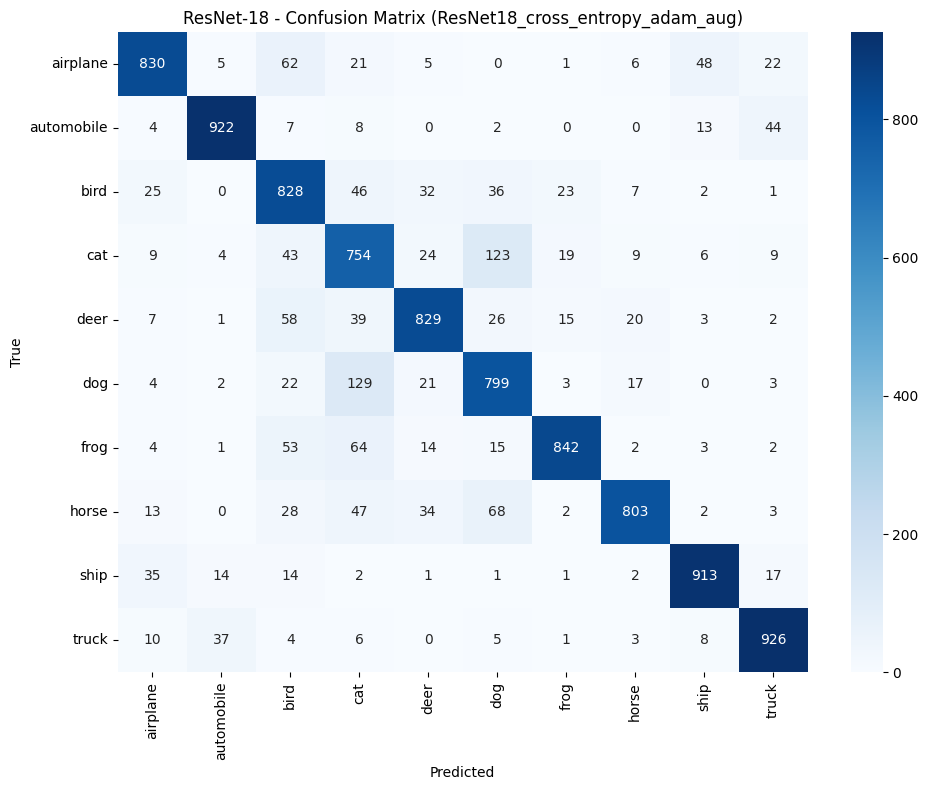


✅ Best model: ResNet-18 - ResNet18_cross_entropy_adam_aug
   Test Accuracy: 84.46%


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get best model
best_model_name = best_resnet if resnet_test_accuracies[best_resnet] > vit_test_accuracies[best_vit] else best_vit
best_model = None
best_model_type = ""

if best_model_name in resnet_results:
    best_model = resnet_results[best_model_name]['model']
    best_model_type = "ResNet-18"
else:
    best_model = vit_results[best_model_name]['model']
    best_model_type = "ViT"

# Evaluate and get predictions
_, preds, labels = evaluate_on_test(best_model, test_loader, device, best_model_name)

# Create confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'{best_model_type} - Confusion Matrix ({best_model_name})')
plt.tight_layout()
plt.savefig(f"{exp_path}/results/best_model_confusion_matrix.png")
plt.show()

print(f"\n✅ Best model: {best_model_type} - {best_model_name}")
print(f"   Test Accuracy: {max(resnet_test_accuracies.values() if best_model_type=='ResNet-18' else vit_test_accuracies.values()):.2f}%")